# Cat vs Dog Classifier - PyTorch Version
This notebook contains the PyTorch implementation of a CNN for binary image classification (cats vs dogs).

In [7]:
# Setup: Create Kaggle credentials directory and download dataset
!mkdir -p ~/.kaggle
!cp gaggle-2.json ~/.kaggle/

cp: cannot stat 'gaggle-2.json': No such file or directory


In [8]:
# Download the dogs vs cats dataset
!kaggle datasets download -d salader/dogsvscats

Dataset URL: https://www.kaggle.com/datasets/salader/dogsvscats
License(s): unknown
100%|██████████████████████████████████████| 1.06G/1.06G [00:52<00:00, 21.9MB/s]



In [6]:
# Extract the dataset
!unzip dogsvscats.zip

Streaming output truncated to the last 5000 lines.
  inflating: train/dogs/dog.4419.jpg  
  inflating: train/dogs/dog.442.jpg  
  inflating: train/dogs/dog.4420.jpg  
  inflating: train/dogs/dog.4421.jpg  
  inflating: train/dogs/dog.4422.jpg  
  inflating: train/dogs/dog.4424.jpg  
  inflating: train/dogs/dog.4425.jpg  
  inflating: train/dogs/dog.4426.jpg  
  inflating: train/dogs/dog.4427.jpg  
  inflating: train/dogs/dog.4431.jpg  
  inflating: train/dogs/dog.4433.jpg  
  inflating: train/dogs/dog.4436.jpg  
  inflating: train/dogs/dog.4438.jpg  
  inflating: train/dogs/dog.4439.jpg  
  inflating: train/dogs/dog.444.jpg  
  inflating: train/dogs/dog.4440.jpg  
  inflating: train/dogs/dog.4441.jpg  
  inflating: train/dogs/dog.4442.jpg  
  inflating: train/dogs/dog.4443.jpg  
  inflating: train/dogs/dog.4444.jpg  
  inflating: train/dogs/dog.4445.jpg  
  inflating: train/dogs/dog.4446.jpg  
  inflating: train/dogs/dog.445.jpg  
  inflating: train/dogs/dog.4450.jpg  
  inflating: tra

In [9]:
# Import necessary libraries
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
import matplotlib.pyplot as plt
import numpy as np
import cv2
import os
from pathlib import Path
from tqdm import tqdm

# Check if GPU is available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


In [11]:
# Define custom Dataset class for loading images from directories
class CatDogDataset(Dataset):
    def __init__(self, directory, transform=None):
        """
        Args:
            directory (str): Path to the dataset directory
            transform (callable, optional): Optional transform to be applied on images
        """
        self.directory = directory
        self.transform = transform
        self.images = []
        self.labels = []

        # Load image paths and labels from directory structure
        for label_idx, category in enumerate(['cats', 'dogs']):
            category_dir = os.path.join(directory, category)
            if os.path.exists(category_dir):
                for img_file in os.listdir(category_dir):
                    img_path = os.path.join(category_dir, img_file)
                    if os.path.isfile(img_path):
                        self.images.append(img_path)
                        self.labels.append(label_idx)  # 0 for cat, 1 for dog

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_path = self.images[idx]
        label = self.labels[idx]

        # Read image
        image = cv2.imread(img_path)
        if image is not None:
            image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
            image = cv2.resize(image, (256, 256))

            if self.transform:
                image = self.transform(image)
            else:
                # Default: convert to tensor and normalize
                image = torch.tensor(image, dtype=torch.float32) / 255.0
                image = image.permute(2, 0, 1)  # HWC to CHW

        return image, label


# Define data transforms
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

# Create datasets
train_dataset = CatDogDataset('/kaggle/input/datasets/salader/dogsvscats/train', transform=transform)
validation_dataset = CatDogDataset('/kaggle/input/datasets/salader/dogsvscats/test', transform=transform)

print(f"Train dataset size: {len(train_dataset)}")
print(f"Validation dataset size: {len(validation_dataset)}")

Train dataset size: 20000
Validation dataset size: 5000


In [13]:
# Create DataLoaders for batch processing
batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)
validation_loader = DataLoader(validation_dataset, batch_size=batch_size, shuffle=False, num_workers=2)

print(f"Train batches: {len(train_loader)}")
print(f"Validation batches: {len(validation_loader)}")

Train batches: 625
Validation batches: 157


In [14]:
# Define the CNN model
class CatDogCNN(nn.Module):
    def __init__(self):
        super(CatDogCNN, self).__init__()

        # First convolutional block
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=0)
        self.bn1 = nn.BatchNorm2d(32)
        self.relu1 = nn.ReLU()
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)

        # Second convolutional block
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=0)
        self.bn2 = nn.BatchNorm2d(64)
        self.relu2 = nn.ReLU()
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)

        # Third convolutional block
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=0)
        self.bn3 = nn.BatchNorm2d(128)
        self.relu3 = nn.ReLU()
        self.pool3 = nn.MaxPool2d(kernel_size=2, stride=2)

        # Flatten layer
        self.flatten = nn.Flatten()

        # Fully connected layers
        self.fc1 = nn.Linear(128 * 30 * 30, 128)  # Adjusted based on input size
        self.dropout1 = nn.Dropout(0.1)
        self.relu_fc1 = nn.ReLU()

        self.fc2 = nn.Linear(128, 64)
        self.dropout2 = nn.Dropout(0.1)
        self.relu_fc2 = nn.ReLU()

        # Output layer for binary classification
        self.fc3 = nn.Linear(64, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        # First block
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu1(x)
        x = self.pool1(x)

        # Second block
        x = self.conv2(x)
        x = self.bn2(x)
        x = self.relu2(x)
        x = self.pool2(x)

        # Third block
        x = self.conv3(x)
        x = self.bn3(x)
        x = self.relu3(x)
        x = self.pool3(x)

        # Fully connected layers
        x = self.flatten(x)
        x = self.fc1(x)
        x = self.dropout1(x)
        x = self.relu_fc1(x)

        x = self.fc2(x)
        x = self.dropout2(x)
        x = self.relu_fc2(x)

        x = self.fc3(x)
        x = self.sigmoid(x)

        return x

# Initialize the model
model = CatDogCNN().to(device)
print("Model initialized successfully!")
print(model)

Model initialized successfully!
CatDogCNN(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1))
  (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu1): ReLU()
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1))
  (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu2): ReLU()
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1))
  (bn3): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu3): ReLU()
  (pool3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc1): Linear(in_features=115200, out_features=128, bias=True)
  (dropout1): Dropout(p=0.1, inplace=False)
  (relu_fc1): ReLU()
  (fc2): Linear(in

In [15]:
# Print model summary
def count_parameters(model):
    total = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return total, trainable

total_params, trainable_params = count_parameters(model)
print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

Total parameters: 14,847,745
Trainable parameters: 14,847,745


In [16]:
# Define loss function and optimizer
criterion = nn.BCELoss()  # Binary Cross Entropy for binary classification
optimizer = optim.Adam(model.parameters())

print("Loss function: BCELoss")
print("Optimizer: Adam")

Loss function: BCELoss
Optimizer: Adam


In [17]:
# Training function
def train_epoch(model, train_loader, criterion, optimizer, device):
    model.train()
    total_loss = 0.0
    correct = 0
    total = 0

    for images, labels in tqdm(train_loader, desc="Training"):
        images = images.to(device)
        labels = labels.to(device).float().unsqueeze(1)  # Add dimension for BCE

        # Forward pass
        outputs = model(images)
        loss = criterion(outputs, labels)

        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        # Calculate accuracy
        predicted = (outputs > 0.5).float()
        correct += (predicted == labels).sum().item()
        total += labels.size(0)

    avg_loss = total_loss / len(train_loader)
    accuracy = 100 * correct / total

    return avg_loss, accuracy


# Validation function
def validate(model, val_loader, criterion, device):
    model.eval()
    total_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in tqdm(val_loader, desc="Validating"):
            images = images.to(device)
            labels = labels.to(device).float().unsqueeze(1)

            outputs = model(images)
            loss = criterion(outputs, labels)

            total_loss += loss.item()

            predicted = (outputs > 0.5).float()
            correct += (predicted == labels).sum().item()
            total += labels.size(0)

    avg_loss = total_loss / len(val_loader)
    accuracy = 100 * correct / total

    return avg_loss, accuracy


print("Training and validation functions defined!")

Training and validation functions defined!


In [18]:
# Train the model
num_epochs = 10
history = {
    'train_loss': [],
    'val_loss': [],
    'train_accuracy': [],
    'val_accuracy': []
}

for epoch in range(num_epochs):
    print(f"\nEpoch [{epoch+1}/{num_epochs}]")

    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc = validate(model, validation_loader, criterion, device)

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_accuracy'].append(train_acc)
    history['val_accuracy'].append(val_acc)

    print(f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}%")
    print(f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}%")

print("\nTraining completed!")


Epoch [1/10]


Validating: 100%|██████████| 157/157 [00:31<00:00,  4.94it/s]


Train Loss: 0.7866, Train Acc: 64.23%
Val Loss: 0.5678, Val Acc: 69.24%

Epoch [2/10]


Validating: 100%|██████████| 157/157 [00:13<00:00, 11.87it/s]


Train Loss: 0.5483, Train Acc: 71.45%
Val Loss: 0.5126, Val Acc: 74.12%

Epoch [3/10]


...

Train Loss: 0.3274, Train Acc: 85.52%
Val Loss: 0.3857, Val Acc: 83.12%

Epoch [9/10]


Validating: 100%|██████████| 157/157 [00:13<00:00, 11.81it/s]


Train Loss: 0.2959, Train Acc: 86.73%
Val Loss: 0.3658, Val Acc: 83.58%

Epoch [10/10]


Validating: 100%|██████████| 157/157 [00:13<00:00, 11.70it/s]

Train Loss: 0.2752, Train Acc: 87.73%
Val Loss: 0.3860, Val Acc: 83.08%

Training completed!


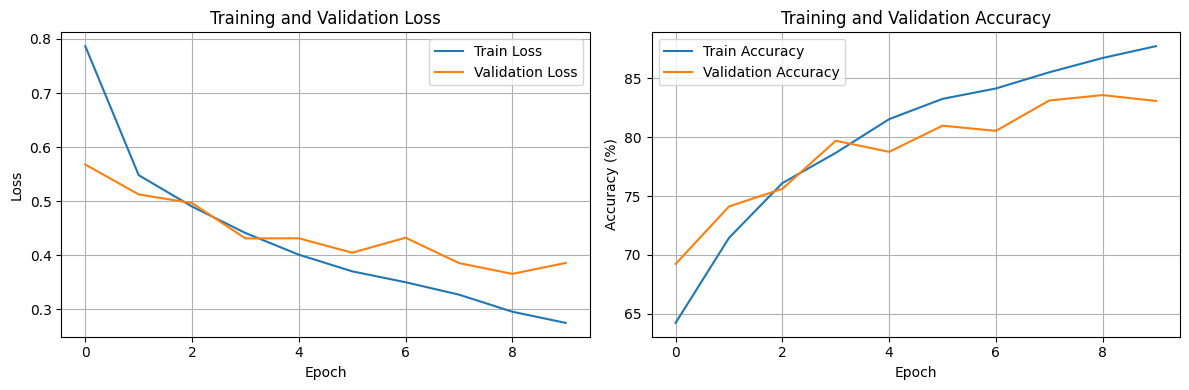

In [19]:
# Plot training history
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history['train_loss'], label='Train Loss')
plt.plot(history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history['train_accuracy'], label='Train Accuracy')
plt.plot(history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.title('Training and Validation Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

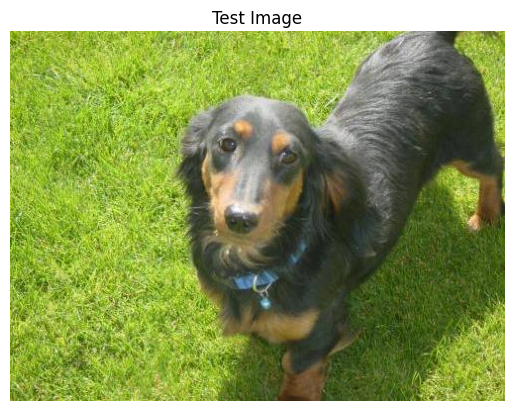


Prediction: DOG
Confidence: 0.7279
Raw output: 0.7279

0 = CAT, 1 = DOG


In [31]:
# Test the model on a single image
test_img_path = '/kaggle/input/datasets/salader/dogsvscats/test/dogs/dog.10032.jpg'

if os.path.exists(test_img_path):
    # Read and preprocess image
    test_img = cv2.imread(test_img_path)
    test_img_rgb = cv2.cvtColor(test_img, cv2.COLOR_BGR2RGB)
    test_img_resized = cv2.resize(test_img_rgb, (256, 256))

    # Display image
    plt.imshow(test_img_rgb)
    plt.axis('off')
    plt.title('Test Image')
    plt.show()

    # Prepare for model prediction
    test_tensor = torch.tensor(test_img_resized, dtype=torch.float32).permute(2, 0, 1).unsqueeze(0) / 255.0
    test_tensor = test_tensor.to(device)

    # Make prediction
    model.eval()
    with torch.no_grad():
        prediction = model(test_tensor)

    pred_value = prediction.item()
    pred_class = 'DOG' if pred_value > 0.5 else 'CAT'
    confidence = pred_value if pred_value > 0.5 else 1 - pred_value

    print(f"\nPrediction: {pred_class}")
    print(f"Confidence: {confidence:.4f}")
    print(f"Raw output: {pred_value:.4f}")
    print("\n0 = CAT, 1 = DOG")
else:
    print(f"Test image not found at {test_img_path}")

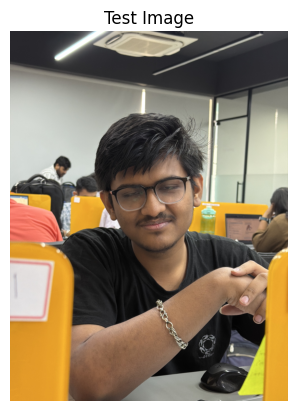


Prediction: CAT
Confidence: 0.6964
Raw output: 0.3036

0 = CAT, 1 = DOG


In [24]:
# Test the model on a single image
test_img_path = '/kaggle/input/datasets/vrundpatel765/boghoo/Image 2.jpeg'

if os.path.exists(test_img_path):
    # Read and preprocess image
    test_img = cv2.imread(test_img_path)
    test_img_rgb = cv2.cvtColor(test_img, cv2.COLOR_BGR2RGB)
    test_img_resized = cv2.resize(test_img_rgb, (256, 256))

    # Display image
    plt.imshow(test_img_rgb)
    plt.axis('off')
    plt.title('Test Image')
    plt.show()

    # Prepare for model prediction
    test_tensor = torch.tensor(test_img_resized, dtype=torch.float32).permute(2, 0, 1).unsqueeze(0) / 255.0
    test_tensor = test_tensor.to(device)

    # Make prediction
    model.eval()
    with torch.no_grad():
        prediction = model(test_tensor)

    pred_value = prediction.item()
    pred_class = 'DOG' if pred_value > 0.5 else 'CAT'
    confidence = pred_value if pred_value > 0.5 else 1 - pred_value

    print(f"\nPrediction: {pred_class}")
    print(f"Confidence: {confidence:.4f}")
    print(f"Raw output: {pred_value:.4f}")
    print("\n0 = CAT, 1 = DOG")
else:
    print(f"Test image not found at {test_img_path}")

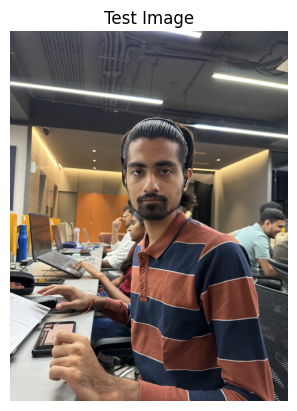


Prediction: DOG
Confidence: 0.8651
Raw output: 0.8651

0 = CAT, 1 = DOG


In [23]:
# Test the model on a single image
test_img_path = '/kaggle/input/datasets/vrundpatel765/jaidev-kutro/Image.jpeg'

if os.path.exists(test_img_path):
    # Read and preprocess image
    test_img = cv2.imread(test_img_path)
    test_img_rgb = cv2.cvtColor(test_img, cv2.COLOR_BGR2RGB)
    test_img_resized = cv2.resize(test_img_rgb, (256, 256))

    # Display image
    plt.imshow(test_img_rgb)
    plt.axis('off')
    plt.title('Test Image')
    plt.show()

    # Prepare for model prediction
    test_tensor = torch.tensor(test_img_resized, dtype=torch.float32).permute(2, 0, 1).unsqueeze(0) / 255.0
    test_tensor = test_tensor.to(device)

    # Make prediction
    model.eval()
    with torch.no_grad():
        prediction = model(test_tensor)

    pred_value = prediction.item()
    pred_class = 'DOG' if pred_value > 0.5 else 'CAT'
    confidence = pred_value if pred_value > 0.5 else 1 - pred_value

    print(f"\nPrediction: {pred_class}")
    print(f"Confidence: {confidence:.4f}")
    print(f"Raw output: {pred_value:.4f}")
    print("\n0 = CAT, 1 = DOG")
else:
    print(f"Test image not found at {test_img_path}")

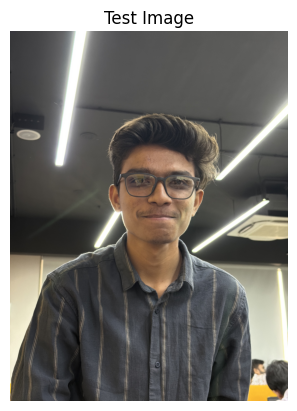


Prediction: DOG
Confidence: 0.7734
Raw output: 0.7734

0 = CAT, 1 = DOG


In [26]:
# Test the model on a single image
test_img_path = '/kaggle/input/datasets/vrundpatel765/bacanciers/Image 3.jpeg'

if os.path.exists(test_img_path):
    # Read and preprocess image
    test_img = cv2.imread(test_img_path)
    test_img_rgb = cv2.cvtColor(test_img, cv2.COLOR_BGR2RGB)
    test_img_resized = cv2.resize(test_img_rgb, (256, 256))

    # Display image
    plt.imshow(test_img_rgb)
    plt.axis('off')
    plt.title('Test Image')
    plt.show()

    # Prepare for model prediction
    test_tensor = torch.tensor(test_img_resized, dtype=torch.float32).permute(2, 0, 1).unsqueeze(0) / 255.0
    test_tensor = test_tensor.to(device)

    # Make prediction
    model.eval()
    with torch.no_grad():
        prediction = model(test_tensor)

    pred_value = prediction.item()
    pred_class = 'DOG' if pred_value > 0.5 else 'CAT'
    confidence = pred_value if pred_value > 0.5 else 1 - pred_value

    print(f"\nPrediction: {pred_class}")
    print(f"Confidence: {confidence:.4f}")
    print(f"Raw output: {pred_value:.4f}")
    print("\n0 = CAT, 1 = DOG")
else:
    print(f"Test image not found at {test_img_path}")

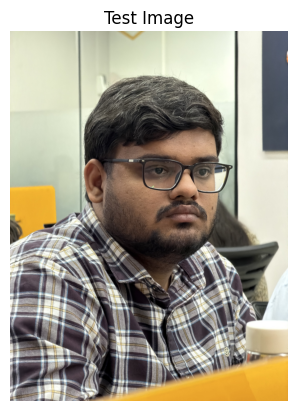


Prediction: DOG
Confidence: 0.9588
Raw output: 0.9588

0 = CAT, 1 = DOG


In [27]:
# Test the model on a single image
test_img_path = '/kaggle/input/datasets/vrundpatel765/bacanciers/Image 4.jpeg'

if os.path.exists(test_img_path):
    # Read and preprocess image
    test_img = cv2.imread(test_img_path)
    test_img_rgb = cv2.cvtColor(test_img, cv2.COLOR_BGR2RGB)
    test_img_resized = cv2.resize(test_img_rgb, (256, 256))

    # Display image
    plt.imshow(test_img_rgb)
    plt.axis('off')
    plt.title('Test Image')
    plt.show()

    # Prepare for model prediction
    test_tensor = torch.tensor(test_img_resized, dtype=torch.float32).permute(2, 0, 1).unsqueeze(0) / 255.0
    test_tensor = test_tensor.to(device)

    # Make prediction
    model.eval()
    with torch.no_grad():
        prediction = model(test_tensor)

    pred_value = prediction.item()
    pred_class = 'DOG' if pred_value > 0.5 else 'CAT'
    confidence = pred_value if pred_value > 0.5 else 1 - pred_value

    print(f"\nPrediction: {pred_class}")
    print(f"Confidence: {confidence:.4f}")
    print(f"Raw output: {pred_value:.4f}")
    print("\n0 = CAT, 1 = DOG")
else:
    print(f"Test image not found at {test_img_path}")

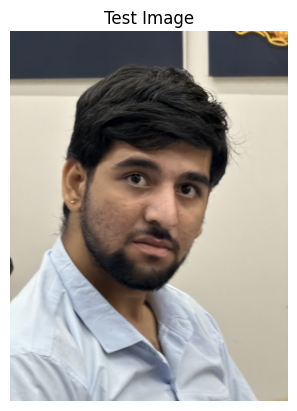


Prediction: CAT
Confidence: 0.5510
Raw output: 0.4490

0 = CAT, 1 = DOG


In [28]:
# Test the model on a single image
test_img_path = '/kaggle/input/datasets/vrundpatel765/bacanciers/Image 5.jpeg'

if os.path.exists(test_img_path):
    # Read and preprocess image
    test_img = cv2.imread(test_img_path)
    test_img_rgb = cv2.cvtColor(test_img, cv2.COLOR_BGR2RGB)
    test_img_resized = cv2.resize(test_img_rgb, (256, 256))

    # Display image
    plt.imshow(test_img_rgb)
    plt.axis('off')
    plt.title('Test Image')
    plt.show()

    # Prepare for model prediction
    test_tensor = torch.tensor(test_img_resized, dtype=torch.float32).permute(2, 0, 1).unsqueeze(0) / 255.0
    test_tensor = test_tensor.to(device)

    # Make prediction
    model.eval()
    with torch.no_grad():
        prediction = model(test_tensor)

    pred_value = prediction.item()
    pred_class = 'DOG' if pred_value > 0.5 else 'CAT'
    confidence = pred_value if pred_value > 0.5 else 1 - pred_value

    print(f"\nPrediction: {pred_class}")
    print(f"Confidence: {confidence:.4f}")
    print(f"Raw output: {pred_value:.4f}")
    print("\n0 = CAT, 1 = DOG")
else:
    print(f"Test image not found at {test_img_path}")